<a href="https://colab.research.google.com/github/hafeezgee/yolo-object-detection/blob/main/Object_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# STEP 1: Install Required Libraries
# ============================================
!pip install ultralytics
!pip install opencv-python-headless
!pip install matplotlib
!pip install ipython
!pip install ipywidgets
!pip install pyyaml

# For webcam support in Colab
!pip install ipywebrtc

# Restart runtime after installation
print("Installation complete! Please restart runtime if needed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.7/260.7 kB 16.4 MB/s eta 0:00:00
Installation complete! Please restart runtime if needed.


In [2]:
# ============================================
# STEP 2: Import Libraries
# ============================================
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from IPython.display import display, Image, clear_output
import ipywidgets as widgets
from google.colab.patches import cv2_imshow
from google.colab import files
import os
import time
from PIL import Image as PILImage

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# ============================================
# STEP 3: Load YOLOv8 Model
# ============================================
# Check if GPU is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Load pre-trained YOLOv8 model (options: yolov8n.pt, yolov8s.pt, yolov8m.pt, yolov8l.pt, yolov8x.pt)
model = YOLO('yolov8n.pt')  # 'n' for nano (fastest), 's' for small, 'm' for medium, etc.

# Move model to GPU if available
if device == 'cuda':
    model.to('cuda')

print("Model loaded successfully!")
print(f"Model classes: {model.names}")

Using device: cpu
Model loaded successfully!
Model classes: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse',

In [4]:
# ============================================
# STEP 4: Helper Functions
# ============================================

def detect_objects(image, conf_threshold=0.5, iou_threshold=0.45):
    """
    Perform object detection on an image
    """
    # Run inference
    results = model(image, conf=conf_threshold, iou=iou_threshold)

    return results

def plot_detections(image, results):
    """
    Plot image with detection boxes and labels
    """
    # Create a copy of the image
    img_copy = image.copy()

    # Get the annotated image from results
    annotated_img = results[0].plot()

    # Convert BGR to RGB for matplotlib
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    # Display
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_img_rgb)
    plt.axis('off')
    plt.title('Object Detection Results')
    plt.show()

    return annotated_img

def get_detection_info(results):
    """
    Extract detection information
    """
    detections = []

    if results[0].boxes is not None:
        for box in results[0].boxes:
            # Get coordinates, confidence, and class
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            confidence = box.conf[0].cpu().numpy()
            class_id = int(box.cls[0].cpu().numpy())
            class_name = model.names[class_id]

            detections.append({
                'class': class_name,
                'class_id': class_id,
                'confidence': confidence,
                'bbox': [x1, y1, x2, y2]
            })

    return detections

In [5]:
# ============================================
# STEP 5: Image Upload and Detection
# ============================================
def process_uploaded_image():
    """
    Upload an image and perform detection
    """
    print("📤 Please upload an image file (jpg, jpeg, png):")
    uploaded = files.upload()

    for filename in uploaded.keys():
        print(f"\n🔍 Processing image: {filename}")

        # Read image
        image = cv2.imread(filename)

        if image is None:
            print("❌ Error: Could not read image")
            continue

        print(f"📐 Image shape: {image.shape}")

        # Perform detection
        start_time = time.time()
        results = detect_objects(image)
        inference_time = time.time() - start_time

        print(f"⏱️  Inference time: {inference_time:.3f} seconds")

        # Get detection information
        detections = get_detection_info(results)

        print(f"\n📊 Detected {len(detections)} objects:")
        for i, det in enumerate(detections, 1):
            print(f"  {i}. {det['class']} (confidence: {det['confidence']:.2f})")

        # Display result
        plot_detections(image, results)

        # Save result
        result_img = results[0].plot()
        output_filename = f"detected_{filename}"
        cv2.imwrite(output_filename, result_img)
        print(f"💾 Result saved as: {output_filename}")

        return results, detections

# Run image detection
# results, detections = process_uploaded_image()

In [6]:
# ============================================
# STEP 6: Real-time Webcam Detection (Colab)
# ============================================
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import PIL

# JavaScript code for webcam capture
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            // Resize the output to fit the video element
            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

def webcam_detection():
    """
    Capture from webcam and perform real-time detection
    """
    print("📸 Webcam Detection Mode")
    print("Click 'Capture' button to take a photo")
    print("Press 'Stop' to exit\n")

    # Create buttons
    capture_btn = widgets.Button(description="Capture Photo")
    stop_btn = widgets.Button(description="Stop")
    output = widgets.Output()

    def on_capture_clicked(b):
        with output:
            clear_output(wait=True)
            print("📷 Capturing...")

            # Take photo
            try:
                image_path = take_photo()
                print("✅ Photo captured!")

                # Read and process image
                image = cv2.imread(image_path)

                # Perform detection
                start_time = time.time()
                results = detect_objects(image)
                inference_time = time.time() - start_time

                # Get detections
                detections = get_detection_info(results)

                print(f"⏱️ Inference time: {inference_time:.3f} seconds")
                print(f"📊 Detected {len(detections)} objects:")
                for det in detections:
                    print(f"  - {det['class']}: {det['confidence']:.2f}")

                # Show result
                result_img = results[0].plot()
                result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
                plt.figure(figsize=(10, 8))
                plt.imshow(result_img_rgb)
                plt.axis('off')
                plt.show()

            except Exception as e:
                print(f"❌ Error: {e}")

    def on_stop_clicked(b):
        with output:
            print("🛑 Stopped webcam detection")
            capture_btn.disabled = True
            stop_btn.disabled = True

    capture_btn.on_click(on_capture_clicked)
    stop_btn.on_click(on_stop_clicked)

    display(capture_btn, stop_btn, output)

# Uncomment to run webcam detection
# webcam_detection()

In [7]:
# ============================================
# STEP 7: Video File Detection
# ============================================
def process_video_file(video_path, conf_threshold=0.5):
    """
    Process a video file for object detection
    """
    print(f"🎬 Processing video: {video_path}")

    # Open video
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("❌ Error: Could not open video")
        return

    # Get video properties
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"📹 Video info: {width}x{height}, {fps} FPS, {total_frames} frames")

    # Create output video writer
    output_path = "detected_video.mp4"
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_count = 0
    start_time = time.time()

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Perform detection
        results = model(frame, conf=conf_threshold)

        # Get annotated frame
        annotated_frame = results[0].plot()

        # Write to output
        out.write(annotated_frame)

        frame_count += 1

        # Progress update
        if frame_count % 30 == 0:
            progress = (frame_count / total_frames) * 100
            print(f"Progress: {progress:.1f}% ({frame_count}/{total_frames})")

    # Cleanup
    cap.release()
    out.release()

    processing_time = time.time() - start_time
    print(f"\n✅ Processing complete!")
    print(f"⏱️ Total time: {processing_time:.2f} seconds")
    print(f"💾 Output saved to: {output_path}")

    return output_path

# Upload and process video
def upload_and_process_video():
    """
    Upload video file and process it
    """
    print("📤 Upload video file (mp4, avi, mov):")
    uploaded = files.upload()

    for filename in uploaded.keys():
        output_path = process_video_file(filename)

        # Display first frame of output
        if os.path.exists(output_path):
            cap = cv2.VideoCapture(output_path)
            ret, frame = cap.read()
            if ret:
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                plt.figure(figsize=(12, 8))
                plt.imshow(frame_rgb)
                plt.title("First frame of detected video")
                plt.axis('off')
                plt.show()
            cap.release()

# Uncomment to process video
# upload_and_process_video()

In [8]:
# ============================================
# STEP 8: Real-time Webcam Stream (Advanced)
# ============================================
from IPython.display import HTML
from base64 import b64encode

def webcam_live_detection():
    """
    Real-time webcam detection using JavaScript
    """
    print("🎥 Starting real-time webcam detection...")
    print("This will open a live video feed with object detection")

    # JavaScript for real-time detection
    html_code = '''
    <div id="container">
        <video id="video" width="640" height="480" autoplay></video>
        <canvas id="canvas" width="640" height="480" style="position: absolute; top: 0; left: 0;"></canvas>
        <button id="startBtn">Start Detection</button>
        <button id="stopBtn">Stop Detection</button>
    </div>

    <script>
    // This is a placeholder - actual implementation requires server-side processing
    // For full real-time detection, consider using local machine or Streamlit
    console.log("For true real-time detection, run this notebook locally or use Streamlit");
    </script>
    '''

    print("\n⚠️ Note: For true real-time webcam detection, Colab has limitations.")
    print("Alternative approaches:")
    print("1. Run locally on your machine")
    print("2. Use Streamlit deployment")
    print("3. Use the capture button method above")

    return HTML(html_code)

# Display information about real-time detection
print("="*50)
print("REAL-TIME DETECTION OPTIONS")
print("="*50)
print("""
Option 1: Use 'webcam_detection()' function for photo capture mode
Option 2: Run locally on your computer for true real-time
Option 3: Use video file processing

For best real-time performance:
- Use Google Colab with GPU runtime
- Process video files instead of live webcam
- Use the smallest model (yolov8n.pt)
- Adjust confidence threshold as needed
""")

REAL-TIME DETECTION OPTIONS

Option 1: Use 'webcam_detection()' function for photo capture mode
Option 2: Run locally on your computer for true real-time
Option 3: Use video file processing

For best real-time performance:
- Use Google Colab with GPU runtime
- Process video files instead of live webcam
- Use the smallest model (yolov8n.pt)
- Adjust confidence threshold as needed



In [9]:
# ============================================
# STEP 9: Batch Processing Multiple Images
# ============================================
def batch_process_images(folder_path=None):
    """
    Process multiple images in a folder
    """
    if folder_path is None:
        # Upload multiple files
        print("📤 Upload multiple images (Ctrl+Click to select multiple):")
        uploaded = files.upload()

        results_summary = []

        for filename, content in uploaded.items():
            print(f"\n🔍 Processing: {filename}")

            # Read image
            image = cv2.imread(filename)

            if image is not None:
                # Detect objects
                results = detect_objects(image)
                detections = get_detection_info(results)

                # Save result
                result_img = results[0].plot()
                output_filename = f"detected_{filename}"
                cv2.imwrite(output_filename, result_img)

                results_summary.append({
                    'filename': filename,
                    'num_detections': len(detections),
                    'detections': detections
                })

                print(f"  ✅ Found {len(detections)} objects")

        # Print summary
        print("\n" + "="*50)
        print("BATCH PROCESSING SUMMARY")
        print("="*50)
        for res in results_summary:
            print(f"\n📄 {res['filename']}: {res['num_detections']} objects detected")
            for det in res['detections'][:3]:  # Show first 3 detections
                print(f"   - {det['class']}: {det['confidence']:.2f}")

    return results_summary

# Run batch processing
# batch_results = batch_process_images()

In [10]:
# ============================================
# STEP 10: Interactive Detection Interface
# ============================================
def create_interactive_interface():
    """
    Create an interactive widget interface for detection
    """
    print("🎮 Creating interactive detection interface...")

    # Create widgets
    conf_slider = widgets.FloatSlider(
        value=0.5,
        min=0.1,
        max=0.9,
        step=0.05,
        description='Confidence:',
        continuous_update=False
    )

    model_dropdown = widgets.Dropdown(
        options=['yolov8n.pt', 'yolov8s.pt', 'yolov8m.pt'],
        value='yolov8n.pt',
        description='Model:'
    )

    upload_btn = widgets.Button(description="Upload Image")
    detect_btn = widgets.Button(description="Detect Objects", disabled=True)
    output_area = widgets.Output()

    current_image = None
    current_filename = None

    def on_upload_clicked(b):
        nonlocal current_image, current_filename
        with output_area:
            output_area.clear_output()
            uploaded = files.upload()
            for filename in uploaded.keys():
                current_filename = filename
                current_image = cv2.imread(filename)
                if current_image is not None:
                    print(f"✅ Image loaded: {filename}")
                    print(f"📐 Size: {current_image.shape}")
                    detect_btn.disabled = False
                else:
                    print("❌ Error loading image")

    def on_detect_clicked(b):
        with output_area:
            output_area.clear_output()

            if current_image is None:
                print("❌ No image loaded")
                return

            # Load selected model
            global model
            model = YOLO(model_dropdown.value)

            # Perform detection
            print(f"🔍 Detecting with {model_dropdown.value}...")
            print(f"Confidence threshold: {conf_slider.value}")

            results = detect_objects(current_image, conf_threshold=conf_slider.value)
            detections = get_detection_info(results)

            print(f"\n📊 Found {len(detections)} objects:")
            for det in detections:
                print(f"  - {det['class']}: {det['confidence']:.2f}")

            # Display result
            result_img = results[0].plot()
            result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(12, 8))
            plt.imshow(result_img_rgb)
            plt.axis('off')
            plt.show()

    upload_btn.on_click(on_upload_clicked)
    detect_btn.on_click(on_detect_clicked)

    # Display interface
    display(widgets.VBox([
        widgets.HBox([model_dropdown, conf_slider]),
        widgets.HBox([upload_btn, detect_btn]),
        output_area
    ]))

# Launch interactive interface
create_interactive_interface()

🎮 Creating interactive detection interface...


In [11]:
# ============================================
# STEP 11: Performance Testing
# ============================================
def test_performance(num_tests=10):
    """
    Test model performance on sample images
    """
    print("🚀 Performance Testing")
    print("="*50)

    # Create test image (random noise)
    test_image = np.random.randint(0, 255, (640, 640, 3), dtype=np.uint8)

    # Test different models
    models_to_test = ['yolov8n.pt', 'yolov8s.pt']

    for model_name in models_to_test:
        print(f"\n📊 Testing {model_name}:")
        test_model = YOLO(model_name)
        if device == 'cuda':
            test_model.to('cuda')

        # Warmup
        for _ in range(3):
            _ = test_model(test_image, verbose=False)

        # Timed tests
        times = []
        for i in range(num_tests):
            start = time.time()
            results = test_model(test_image, verbose=False)
            end = time.time()
            times.append(end - start)

        avg_time = np.mean(times)
        fps = 1 / avg_time

        print(f"  Average inference time: {avg_time*1000:.2f} ms")
        print(f"  FPS: {fps:.2f}")

    print("\n" + "="*50)
    print("💡 Tips for better performance:")
    print("  - Use smaller model (yolov8n.pt for speed)")
    print("  - Reduce image size")
    print("  - Use GPU runtime in Colab")
    print("  - Increase batch size for multiple images")

# Run performance test
test_performance()

🚀 Performance Testing

📊 Testing yolov8n.pt:
  Average inference time: 273.84 ms
  FPS: 3.65

📊 Testing yolov8s.pt:
  Average inference time: 592.98 ms
  FPS: 1.69

💡 Tips for better performance:
  - Use smaller model (yolov8n.pt for speed)
  - Reduce image size
  - Use GPU runtime in Colab
  - Increase batch size for multiple images


In [12]:
# ============================================
# QUICK START GUIDE
# ============================================
print("""
╔══════════════════════════════════════════════════════════════╗
║           YOLOv8 REAL-TIME OBJECT DETECTION GUIDE           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  QUICK START:                                               ║
║  1. Run all cells above                                      ║
║  2. For IMAGE detection: Run process_uploaded_image()       ║
║  3. For WEBCAM: Run webcam_detection()                      ║
║  4. For VIDEO: Run upload_and_process_video()               ║
║  5. For INTERACTIVE UI: Run create_interactive_interface()  ║
║                                                              ║
║  TIPS:                                                      ║
║  • Enable GPU: Runtime → Change runtime type → GPU         ║
║  • Adjust confidence threshold for better results          ║
║  • Use smaller model (yolov8n.pt) for faster detection     ║
║  • For true real-time, run locally with webcam             ║
║                                                              ║
║  MODEL OPTIONS:                                             ║
║  • yolov8n.pt - Nano (fastest, less accurate)              ║
║  • yolov8s.pt - Small (good balance)                       ║
║  • yolov8m.pt - Medium (more accurate, slower)             ║
║  • yolov8l.pt - Large (very accurate)                      ║
║  • yolov8x.pt - Extra Large (best accuracy)                ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")

# Example usage:
print("\n📝 EXAMPLE USAGE:")
print("-" * 40)
print("""
# Detect objects in an uploaded image:
results, detections = process_uploaded_image()

# Use webcam (photo capture mode):
webcam_detection()

# Process a video file:
upload_and_process_video()

# Use interactive interface:
create_interactive_interface()

# Test performance:
test_performance()
""")


╔══════════════════════════════════════════════════════════════╗
║           YOLOv8 REAL-TIME OBJECT DETECTION GUIDE           ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  QUICK START:                                               ║
║  1. Run all cells above                                      ║
║  2. For IMAGE detection: Run process_uploaded_image()       ║
║  3. For WEBCAM: Run webcam_detection()                      ║
║  4. For VIDEO: Run upload_and_process_video()               ║
║  5. For INTERACTIVE UI: Run create_interactive_interface()  ║
║                                                              ║
║  TIPS:                                                      ║
║  • Enable GPU: Runtime → Change runtime type → GPU         ║
║  • Adjust confidence threshold for better results          ║
║  • Use smaller model (yolov8n.pt) for faster detection     ║
║  • For true real-time, run locally 

In [14]:
# Use webcam (photo capture mode):
webcam_detection()

📸 Webcam Detection Mode
Click 'Capture' button to take a photo
Press 'Stop' to exit



Button(description='Capture Photo', style=ButtonStyle())

Button(description='Stop', style=ButtonStyle())

Output()

📤 Upload video file (mp4, avi, mov):


Saving download.jpg to download.jpg
🎬 Processing video: download.jpg
📹 Video info: 166x304, 25 FPS, 1 frames

0: 640x352 1 car, 1 cat, 151.1ms
Speed: 3.5ms preprocess, 151.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 352)

✅ Processing complete!
⏱️ Total time: 0.20 seconds
💾 Output saved to: detected_video.mp4


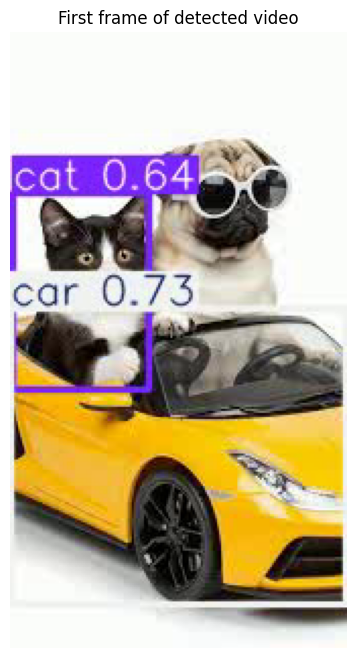

In [15]:
# Process a video file:
upload_and_process_video()

In [17]:
# Use interactive interface:
create_interactive_interface()

🎮 Creating interactive detection interface...


In [18]:
# Test performance:
test_performance()

🚀 Performance Testing

📊 Testing yolov8n.pt:
  Average inference time: 330.43 ms
  FPS: 3.03

📊 Testing yolov8s.pt:
  Average inference time: 617.98 ms
  FPS: 1.62

💡 Tips for better performance:
  - Use smaller model (yolov8n.pt for speed)
  - Reduce image size
  - Use GPU runtime in Colab
  - Increase batch size for multiple images
